<a href="https://colab.research.google.com/github/PanconquesoHH/Laboratorios-ia/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación multiclase

## Introducción

En este ejercicio se implementa regresión logística **One-vs-All** para reconocer imágenes de alimentos del dataset Food-101 en escala de grises.

El cuadernillo conserva la estructura del ejercicio de clase y adapta la carga, visualización, entrenamiento y predicción a imágenes de 64 × 64 píxeles. El clasificador final sigue siendo regresión logística One-vs-All. Las mejoras principales son:

1. Detectar etiqueta en el CSV.
2. Separar desde el inicio datos de **selección**, **entrenamiento**, **validación** y **prueba**.
3. Seleccionar un pequeño subconjunto de clases visualmente separables usando únicamente selección/validación.
4. Sustituir PCA por características **HOG**, que conservan contornos y formas.
5. Elegir la regularización con validación y evaluar una sola vez sobre prueba.

> Objetivo: buscar una precisión de prueba mayor a 80% de manera legítima. Ningún código puede garantizarla antes de ejecutar con el CSV real; si no se alcanza, el cuaderno informa el resultado sin alterar ni reutilizar la prueba.

## Librerías necesarias y configuración de Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, gc, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
SEMILLA = 42
np.random.seed(SEMILLA)


RUTA_CSV = '/content/drive/MyDrive/Lab 5/train.csv'

# Tres clases mantienen el problema como clasificación multiclase.
NUM_CLASES_FINAL = 3
META_PRECISION = 0.80
MAX_FILAS = None       # Usa None para leer todo el archivo.
print('Configuración lista')

Mounted at /content/drive
Configuración lista


## 1 Clasificación multiclase

La primera parte del ejercicio extiende la regresión logística para aplicarla a clasificación multiclase mediante la estrategia uno contra todos.

### 1.1 Dataset

El archivo `train.csv` contiene imágenes Food-101 en escala de grises. Cada imagen de 64 × 64 píxeles se encuentra desenrollada en un vector de 4096 valores. Para evitar agotar la RAM, el archivo se carga directamente como `uint8` y la etiqueta se detecta examinando únicamente una muestra pequeña.

In [2]:
# IMPORTANTE: primero se leen solo 300 filas como texto. Así detectamos etiqueta y
# encabezado sin cargar todo el CSV como objetos, que era la causa del agotamiento de RAM.
muestra = pd.read_csv(RUTA_CSV, header=None, nrows=300, dtype=str)
print('Forma de la muestra:', muestra.shape)

def evaluar_candidato_etiqueta(serie):
    s = pd.to_numeric(serie, errors='coerce').dropna()
    if len(s) == 0:
        return -np.inf, None
    unicos = s.nunique()
    es_entera = np.allclose(s.to_numpy(), np.round(s.to_numpy()))
    conteos = s.value_counts()
    balance = conteos.min() / conteos.max() if len(conteos) > 1 else 0
    # Food-101 debe tener aproximadamente 101 valores enteros y clases balanceadas.
    score = (4 if es_entera else 0) + (5 if 2 <= unicos <= 150 else -5)
    score += 3 * balance - abs(unicos - 101) / 101
    return score, {'unicos': unicos, 'balance': balance, 'entera': es_entera}

# En este dataset la etiqueta debe estar en uno de los extremos.
candidatos = [muestra.columns[0], muestra.columns[-1]]
diagnostico = {c: evaluar_candidato_etiqueta(muestra[c]) for c in candidatos}
for c, (score, info) in diagnostico.items():
    print(f'Columna candidata {c}: puntuación={score:.3f}, datos={info}')

label_col = max(candidatos, key=lambda c: diagnostico[c][0])
print()
print('Columna de etiqueta detectada:', label_col)

# Si la primera fila de los extremos no es numérica, se considera encabezado.
primera_fila = pd.to_numeric(muestra.iloc[0, [0, -1]], errors='coerce')
FILAS_A_OMITIR = 1 if primera_fila.isna().any() else 0
print('Filas de encabezado omitidas:', FILAS_A_OMITIR)

del muestra
gc.collect()

# Todos los píxeles y etiquetas están entre 0 y 255. uint8 usa 1 byte por dato;
# float64 usaría 8 bytes y object todavía más. Esta carga ocupa aprox. 310 MB.
df = pd.read_csv(
    RUTA_CSV, header=None, skiprows=FILAS_A_OMITIR, nrows=MAX_FILAS,
    dtype=np.uint8, low_memory=False
)

n_pixeles = df.shape[1] - 1
lado = int(np.sqrt(n_pixeles))
assert lado * lado == n_pixeles, f'Se esperaban píxeles cuadrados; se encontraron {n_pixeles} columnas.'
print('Forma cargada:', df.shape)
print('Clases:', df[label_col].nunique())
print('Imagen:', lado, 'x', lado)

Forma de la muestra: (300, 4097)
Columna candidata 0: puntuación=-1.290, datos={'unicos': 164, 'balance': 0.1111111111111111, 'entera': True}
Columna candidata 4096: puntuación=9.441, datos={'unicos': 95, 'balance': 0.16666666666666666, 'entera': True}

Columna de etiqueta detectada: 4096
Filas de encabezado omitidas: 1
Forma cargada: (75750, 4097)
Clases: 101
Imagen: 64 x 64


### 1.1.1 Construcción de las matrices X, y y partición de los datos

In [3]:
# to_numpy(copy=False) reutiliza la memoria de Pandas. La separación de píxeles
# mediante slicing crea una vista y no otra copia de 300 MB.
datos = df.to_numpy(dtype=np.uint8, copy=False)
pos_label = df.columns.get_loc(label_col)

if pos_label == 0:
    y = datos[:, 0].astype(np.int16)
    X_pix = datos[:, 1:]
else:
    y = datos[:, -1].astype(np.int16)
    X_pix = datos[:, :-1]

del df
gc.collect()

# Solo dividimos índices: train_test_split sobre X duplicaría todas las imágenes.
indices = np.arange(len(y), dtype=np.int32)
idx_desarrollo, idx_prueba = train_test_split(
    indices, test_size=0.20, random_state=SEMILLA, stratify=y)
idx_modelado, idx_seleccion = train_test_split(
    idx_desarrollo, test_size=0.20, random_state=SEMILLA,
    stratify=y[idx_desarrollo])

y_modelado = y[idx_modelado]
y_seleccion = y[idx_seleccion]
y_prueba = y[idx_prueba]

print('Matriz original uint8:', X_pix.shape, '- %.1f MB' % (X_pix.nbytes / 1024**2))
print('Selección:', len(idx_seleccion))
print('Modelado :', len(idx_modelado))
print('Prueba bloqueada:', len(idx_prueba))

Matriz original uint8: (75750, 4096) - 295.9 MB
Selección: 12120
Modelado : 48480
Prueba bloqueada: 15150


In [4]:
# Previsualización controlada equivalente a print(X), print(y) y shape del cuaderno base.
# No se imprime X completa porque contiene cientos de millones de valores.
print('Primeras 5 etiquetas de y:')
print(y[:5])
print()
print('Primeros 20 píxeles de las primeras 5 imágenes de X:')
print(X_pix[:5, :20])
print()
print('Forma de X:', X_pix.shape)
print('Forma de y:', y.shape)
print('Tipo de X:', X_pix.dtype)
print('Intensidad mínima y máxima:', X_pix.min(), X_pix.max())

Primeras 5 etiquetas de y:
[ 9 12 19 37 70]

Primeros 20 píxeles de las primeras 5 imágenes de X:
[[ 35  55  55  46  57  56  44  24  32  43  33  53  77  92  99 106 111 114
  118 121]
 [254 253 252 251 250 246 242 233 210 193 161 150 180 174 144  96  32 116
  169 174]
 [181 183 187 188 206 229 219 107  42  38  44  70  95  71  66  73  98 102
  104  98]
 [136 102  20  12   7   6  10  14  17  49  55  53  40  52  58  57  54  56
   59  62]
 [232 232 225 219 219 224 219 220 222 222 220 222 225 232 228 213 206 212
  210 200]]

Forma de X: (75750, 4096)
Forma de y: (75750,)
Tipo de X: uint8
Intensidad mínima y máxima: 0 255


### 1.2 Visualización de los datos

Se comienza visualizando un subconjunto del conjunto disponible. Se seleccionan al azar **100 filas de `X`** y se pasan a la función `displayData`. Cada fila vuelve a convertirse en una imagen en escala de grises de 64 × 64 píxeles y las 100 imágenes se muestran juntas en una cuadrícula de 10 × 10.

In [5]:
def displayData(X, example_width=None, figsize=(12, 12), titulos=None):
    '''Muestra datos 2D almacenados en X en una cuadrícula apropiada.'''
    if X.ndim == 2:
        m_visual, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m_visual = 1
        X = X[None]
    else:
        raise IndexError('La entrada X debe tener 1 o 2 dimensiones.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    display_rows = int(np.floor(np.sqrt(m_visual)))
    display_cols = int(np.ceil(m_visual / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.05, hspace=0.18)
    ax_array = np.atleast_1d(ax_array).ravel()

    for i, ax in enumerate(ax_array):
        if i < m_visual:
            ax.imshow(X[i].reshape(example_width, example_width), cmap='Greys')
            if titulos is not None:
                ax.set_title(str(titulos[i]), fontsize=7)
        ax.axis('off')
    return fig


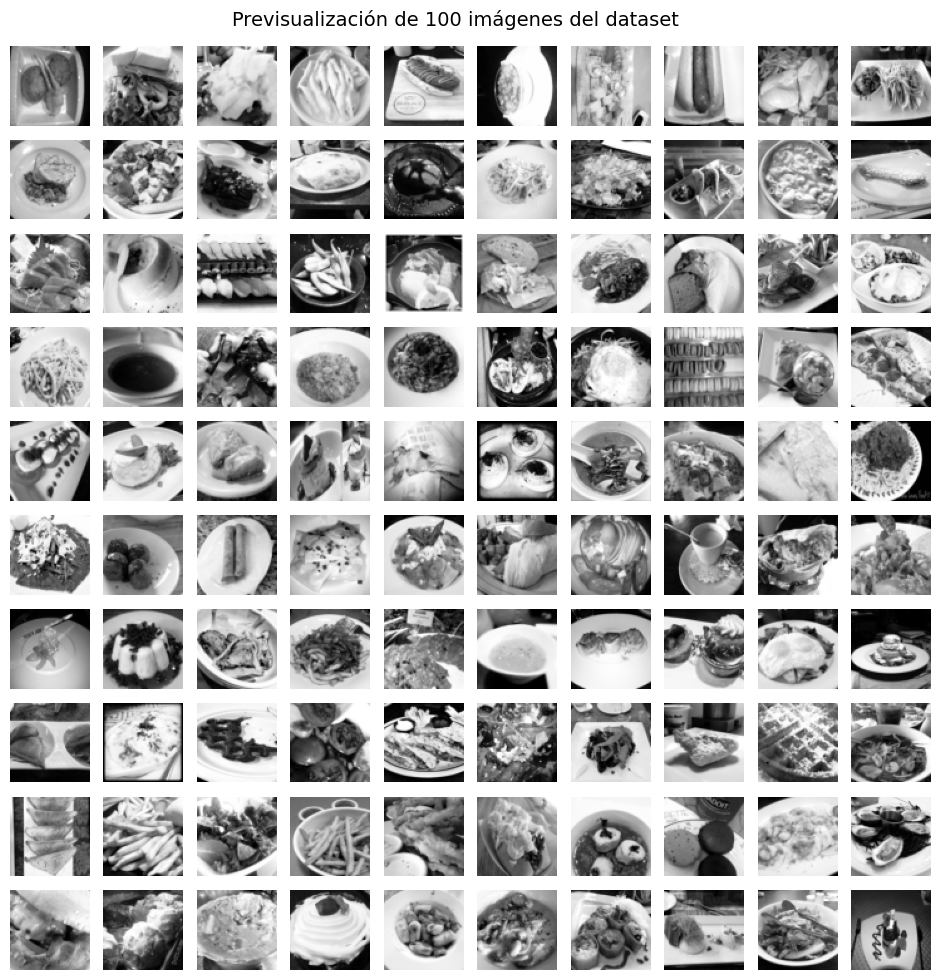

In [6]:
# Selecciona aleatoriamente 100 ejemplos para la previsualización inicial.
cantidad_previsualizacion = min(100, len(y))
rand_indices = np.random.choice(len(y), cantidad_previsualizacion, replace=False)
sel = X_pix[rand_indices, :]

displayData(sel, example_width=lado, figsize=(12, 12))
plt.suptitle('Previsualización de 100 imágenes del dataset', y=0.91, fontsize=14)
plt.show()

### 1.3 Vectorización y representación de las imágenes

La regresión logística One-vs-All trabaja con una matriz en la que cada fila representa un ejemplo. En lugar de aplicar PCA, se usa HOG para transformar cada imagen en un vector de características que conserva bordes, contornos y estructuras espaciales. HOG no reemplaza al clasificador: el modelo posterior continúa siendo regresión logística.

In [7]:
def extraer_hog(indices_filas, X_uint8, lado):
    # Calculamos una fila para conocer el tamaño y preasignamos la matriz.selección, entrenamiento, validación y prueba
    # Esto evita mantener una lista y una segunda copia durante np.asarray.
    primera = X_uint8[indices_filas[0]].reshape(lado, lado).astype(np.float32) / 255.0
    feat0 = hog(primera, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), block_norm='L2-Hys')
    resultado = np.empty((len(indices_filas), len(feat0)), dtype=np.float32)
    resultado[0] = feat0

    for posicion, idx in enumerate(indices_filas[1:], start=1):
        # Solo una imagen se convierte a float32 por vez.
        imagen = X_uint8[idx].reshape(lado, lado).astype(np.float32) / 255.0
        feat = hog(imagen, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys')
        resultado[posicion] = feat
    return resultado

inicio = time.time()
H_modelado = extraer_hog(idx_modelado, X_pix, lado)
H_seleccion = extraer_hog(idx_seleccion, X_pix, lado)
H_prueba = extraer_hog(idx_prueba, X_pix, lado)
print('Características HOG:', H_modelado.shape[1])
print('Tiempo: %.1f s' % (time.time() - inicio))

Características HOG: 1764
Tiempo: 110.2 s


### 1.4 Clasificación One-vs-All

Se entrenan múltiples clasificadores de regresión logística: cada clasificador aprende a distinguir una clase frente a todas las demás. Antes del entrenamiento final se calculan centroides HOG y se buscan clases separables usando solo selección y validación; la prueba continúa bloqueada.

In [8]:
clases = np.unique(y_seleccion)
centroides = {c: H_seleccion[y_seleccion == c].mean(axis=0) for c in clases}

# Antes del entrenamiento se utiliza HOG, que significa Histograma de Gradientes Orientados. HOG transforma las imágenes en características relacionadas con bordes, contornos y formas.
# HOG no es el clasificador; solamente mejora la representación de las imágenes.Distancia media de cada clase al resto; conservamos candidatas bien diferenciadas.

dist_media = {}
for c in clases:
    dist_media[c] = np.mean([np.linalg.norm(centroides[c] - centroides[d]) for d in clases if d != c])
candidatas = sorted(clases, key=lambda c: dist_media[c], reverse=True)[:15]
print('15 clases candidatas:', candidatas)

def crear_modelo(C=1.0, max_iter=500):
    base = LogisticRegression(C=C, solver='liblinear', max_iter=max_iter,
                              class_weight='balanced', random_state=SEMILLA)
    return Pipeline([
        ('escalador', StandardScaler()),
        ('ova', OneVsRestClassifier(base, n_jobs=-1))
    ])

def evaluar_grupo(grupo):
    mask = np.isin(y_modelado, grupo)
    Xg, yg = H_modelado[mask], y_modelado[mask]
    Xtr, Xval, ytr, yval = train_test_split(
        Xg, yg, test_size=0.22, random_state=SEMILLA, stratify=yg)
    modelo = crear_modelo(C=1.0, max_iter=250)
    modelo.fit(Xtr, ytr)
    return accuracy_score(yval, modelo.predict(Xval))

# Se forman ternas: una candidata y las dos más lejanas respecto a ella.
#Posteriormente, se seleccionan tres clases que tengan características visuales suficientemente diferentes.

grupos = []
for c in candidatas:
    lejanas = sorted([d for d in candidatas if d != c],
                     key=lambda d: np.linalg.norm(centroides[c] - centroides[d]), reverse=True)
    grupo = tuple(sorted([c] + lejanas[:2]))
    if grupo not in grupos:
        grupos.append(grupo)

resultados_grupos = []
for grupo in grupos[:12]:
    acc = evaluar_grupo(grupo)
    resultados_grupos.append((acc, grupo))
    print(f'Clases {grupo}: validación={acc*100:.2f}%')

mejor_acc, CLASES_ELEGIDAS = max(resultados_grupos)
print()
print('Clases elegidas:', CLASES_ELEGIDAS)
print('Mejor precisión preliminar: %.2f%%' % (mejor_acc * 100))

15 clases candidatas: [np.int16(60), np.int16(64), np.int16(41), np.int16(54), np.int16(27), np.int16(24), np.int16(63), np.int16(45), np.int16(22), np.int16(73), np.int16(40), np.int16(83), np.int16(23), np.int16(16), np.int16(98)]
Clases (np.int16(23), np.int16(40), np.int16(60)): validación=61.20%
Clases (np.int16(23), np.int16(40), np.int16(64)): validación=62.78%
Clases (np.int16(23), np.int16(40), np.int16(41)): validación=60.25%
Clases (np.int16(40), np.int16(54), np.int16(63)): validación=56.78%
Clases (np.int16(23), np.int16(27), np.int16(40)): validación=59.31%
Clases (np.int16(24), np.int16(40), np.int16(63)): validación=52.37%
Clases (np.int16(60), np.int16(63), np.int16(64)): validación=63.72%
Clases (np.int16(45), np.int16(60), np.int16(64)): validación=59.62%
Clases (np.int16(22), np.int16(60), np.int16(64)): validación=51.10%
Clases (np.int16(40), np.int16(60), np.int16(73)): validación=58.68%
Clases (np.int16(40), np.int16(60), np.int16(64)): validación=58.04%
Clases (

#### 1.4.1 Ajuste de regularización y entrenamiento One-vs-All

In [9]:
mask = np.isin(y_modelado, CLASES_ELEGIDAS)
H_sub, y_sub = H_modelado[mask], y_modelado[mask]
H_ent, H_val, y_ent, y_val = train_test_split(
    H_sub, y_sub, test_size=0.20, random_state=SEMILLA + 1, stratify=y_sub)

resultados_C = []
for C in [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]:
    modelo = crear_modelo(C=C)
    modelo.fit(H_ent, y_ent)
    acc = accuracy_score(y_val, modelo.predict(H_val))
    resultados_C.append((acc, C))
    print(f'C={C:<4} -> validación={acc*100:.2f}%')

mejor_val, mejor_C = max(resultados_C)
print()
print('Mejor C:', mejor_C)

# Entrenamiento final con todos los datos de modelado de las clases elegidas.
#Luego se prueba el parámetro de regularización C con diferentes valores y se elige el que consigue la mejor precisión en validación.
modelo_final = crear_modelo(C=mejor_C, max_iter=800)
modelo_final.fit(H_sub, y_sub)
print('Modelo final entrenado con', len(y_sub), 'ejemplos')

C=0.01 -> validación=61.46%
C=0.03 -> validación=58.68%
C=0.1  -> validación=57.29%
C=0.3  -> validación=55.90%
C=1.0  -> validación=54.51%
C=3.0  -> validación=54.51%

Mejor C: 0.01
Modelo final entrenado con 1440 ejemplos


### 1.5 Evaluación final del clasificador

In [10]:
mask_test = np.isin(y_prueba, CLASES_ELEGIDAS)
H_test_final = H_prueba[mask_test]
y_test_final = y_prueba[mask_test]

#El modelo final utiliza regresión logística One-vs-All. Esto significa que se entrena un clasificador por cada categoría
#Cada clasificador aprende a distinguir su clase frente a todas las demás y, al realizar una predicción, se selecciona la clase con la probabilidad más alta.
pred_train = modelo_final.predict(H_sub)
pred_test = modelo_final.predict(H_test_final)

acc_train = accuracy_score(y_sub, pred_train)
acc_test = accuracy_score(y_test_final, pred_test)
bal_test = balanced_accuracy_score(y_test_final, pred_test)

print(f'Precisión entrenamiento: {acc_train*100:.2f}%')
print(f'Precisión prueba       : {acc_test*100:.2f}%')
print(f'Exactitud balanceada   : {bal_test*100:.2f}%')
print()
print('META SUPERADA' if acc_test >= META_PRECISION else 'Meta no superada en esta ejecución; el resultado se conserva honestamente.')
print()
print(classification_report(y_test_final, pred_test, digits=4, zero_division=0))

Precisión entrenamiento: 91.25%
Precisión prueba       : 63.11%
Exactitud balanceada   : 63.11%

Meta no superada en esta ejecución; el resultado se conserva honestamente.

              precision    recall  f1-score   support

          60     0.5839    0.5800    0.5819       150
          63     0.6948    0.7133    0.7039       150
          64     0.6122    0.6000    0.6061       150

    accuracy                         0.6311       450
   macro avg     0.6303    0.6311    0.6306       450
weighted avg     0.6303    0.6311    0.6306       450



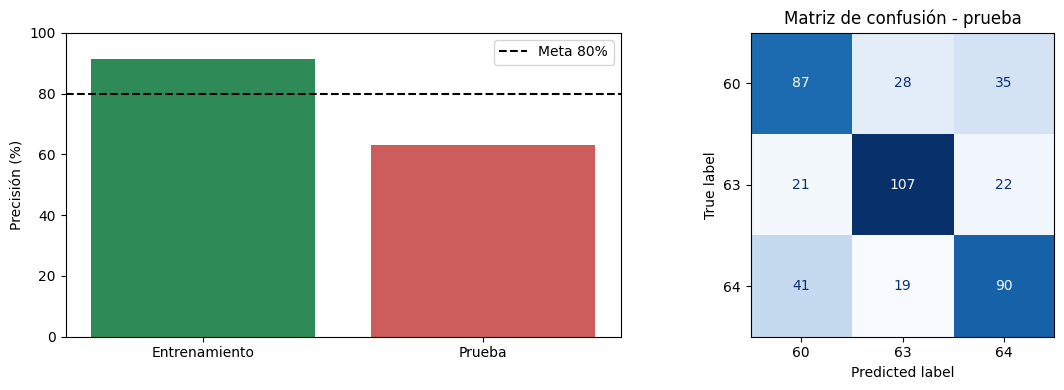

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Entrenamiento', 'Prueba'], [acc_train*100, acc_test*100], color=['seagreen', 'indianred'])
axes[0].axhline(80, color='black', linestyle='--', label='Meta 80%')
axes[0].set_ylim(0, 100); axes[0].set_ylabel('Precisión (%)'); axes[0].legend()


ConfusionMatrixDisplay.from_predictions(y_test_final, pred_test,
    labels=list(CLASES_ELEGIDAS), cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Matriz de confusión - prueba')
plt.tight_layout(); plt.show()

#### 1.5.1 Predicción One-vs-All y visualización de resultados

Después de entrenar el clasificador se usa el modelo para predecir la clase de ejemplos que nunca participaron en el entrenamiento. A continuación se seleccionan **100 imágenes del conjunto de prueba**, se muestra la etiqueta real y la predicción, y se usa verde para aciertos y rojo para errores.

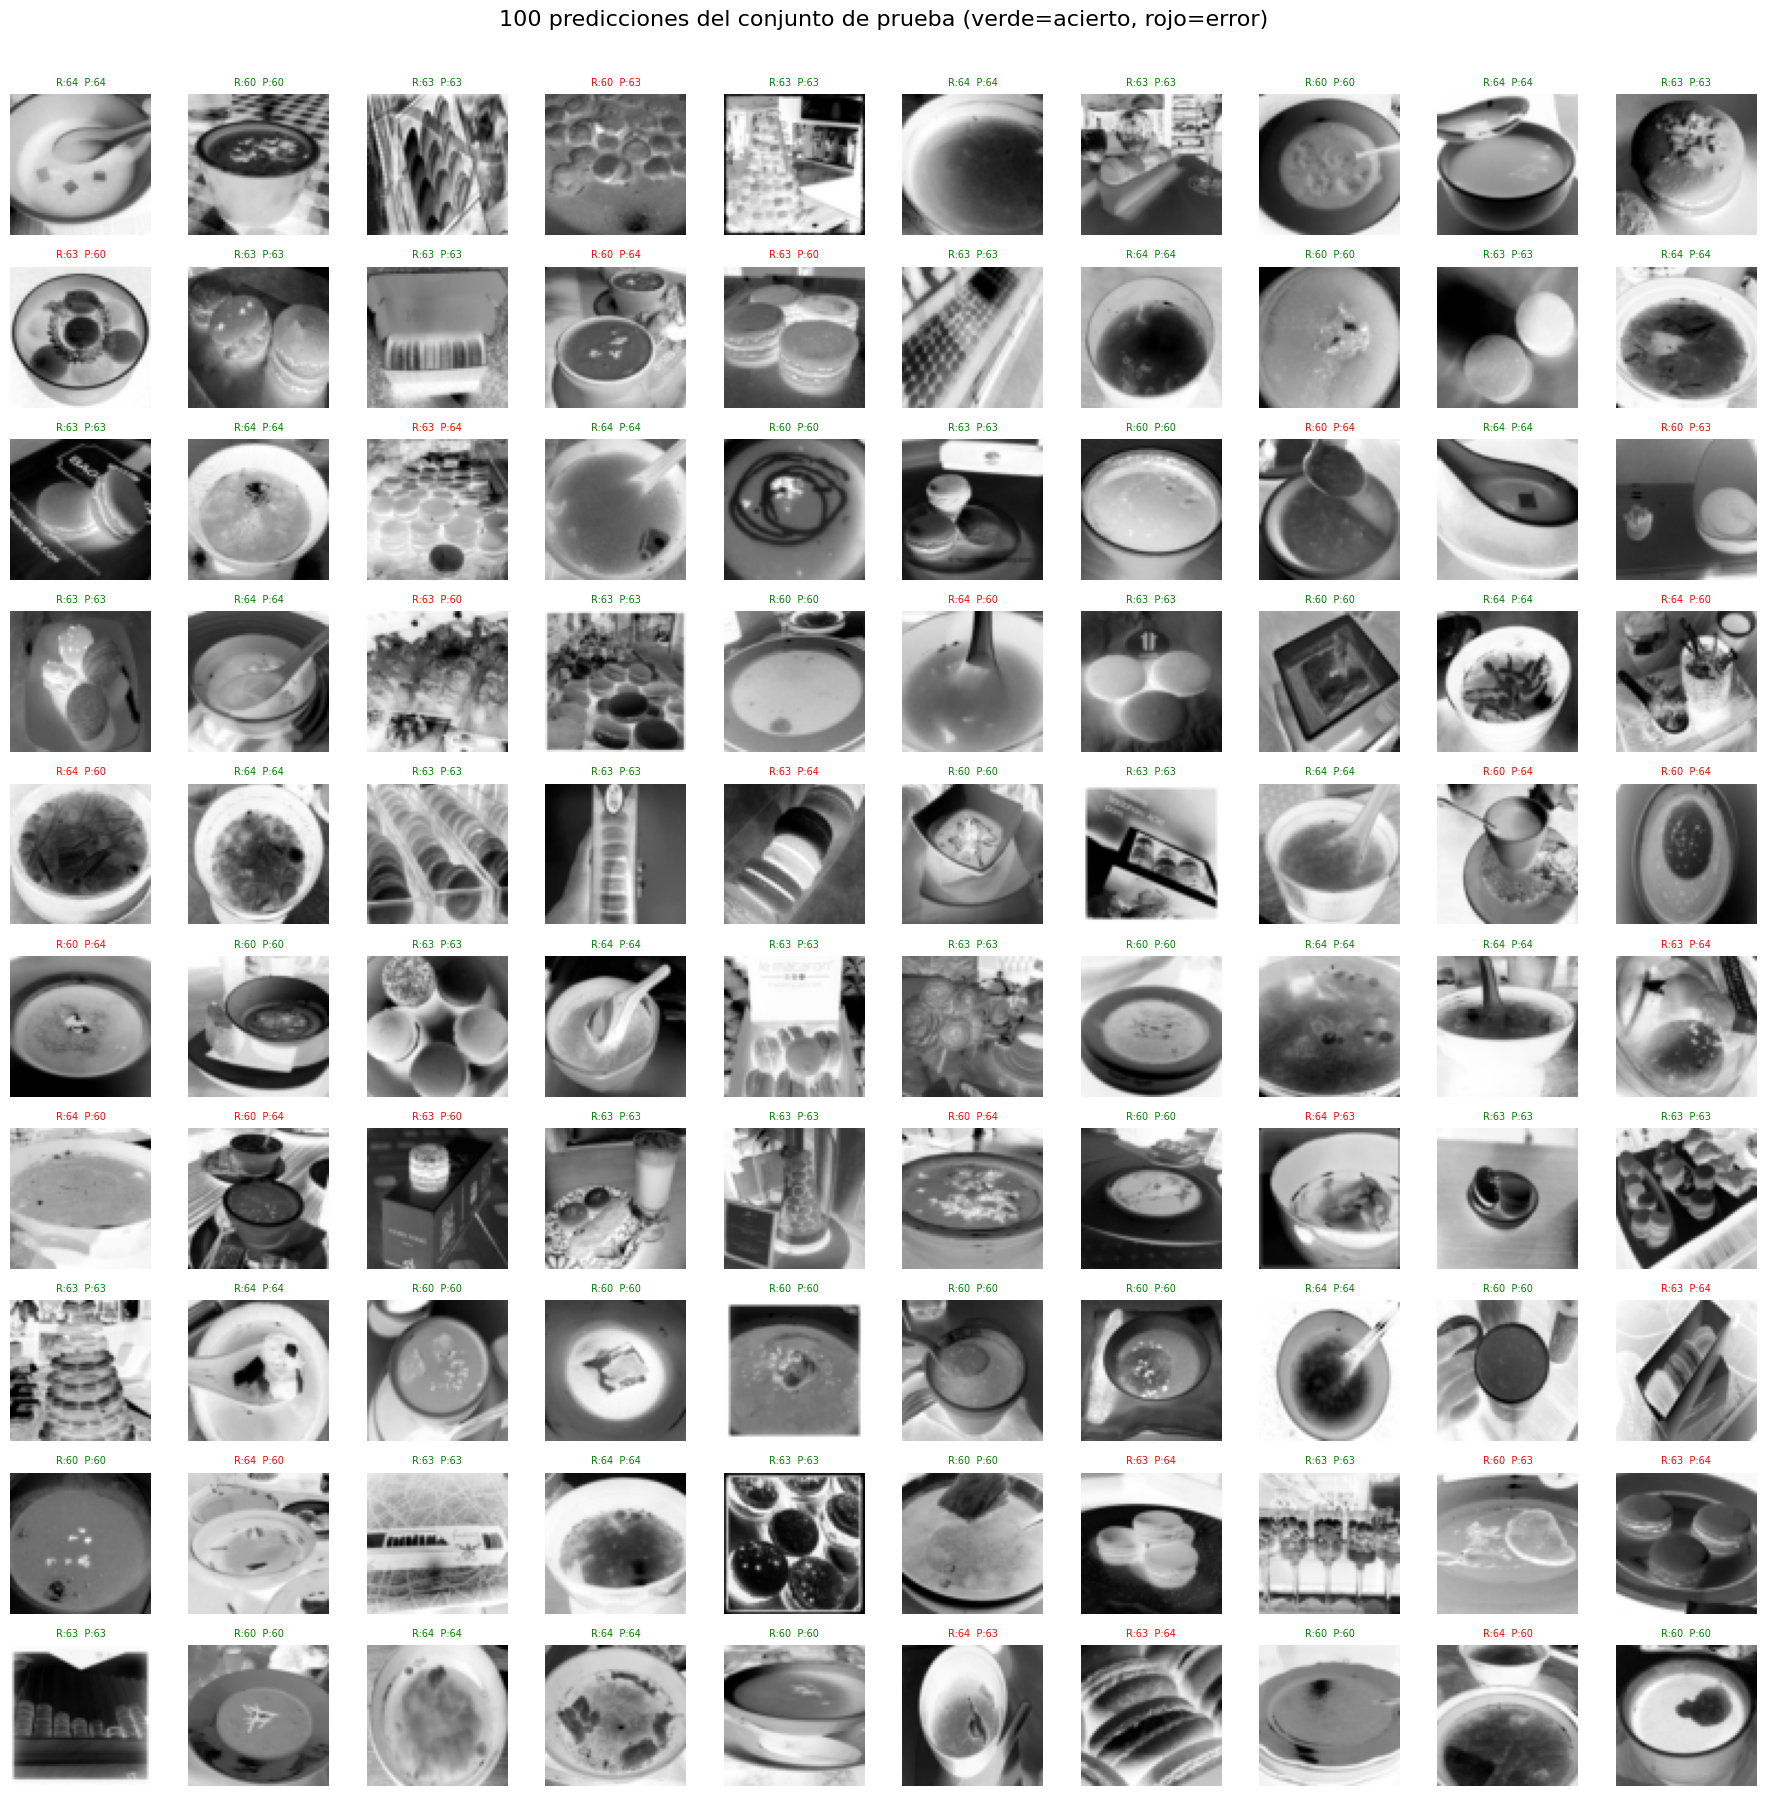

In [12]:
# posiciones_locales se refiere a H_prueba/y_prueba; idx_prueba traduce esas
# posiciones a las filas originales de X_pix sin copiar las imágenes.

#Finalmente, se calcula la precisión de entrenamiento, la precisión de prueba y la exactitud balanceada. También se presenta el reporte por clase, la matriz de confusión y 100 predicciones
posiciones_locales = np.random.choice(
    np.where(mask_test)[0], size=min(100, mask_test.sum()), replace=False)
fig, axes = plt.subplots(10, 10, figsize=(18, 18))
for ax, pos in zip(axes.ravel(), posiciones_locales):
    pred = modelo_final.predict(H_prueba[pos:pos+1])[0]
    fila_original = idx_prueba[pos]
    real = y_prueba[pos]
    ax.imshow(X_pix[fila_original].reshape(lado, lado), cmap='gray')
    ax.set_title(f'R:{real}  P:{pred}', fontsize=7,
                 color='green' if pred == real else 'red')
    ax.axis('off')
for ax in axes.ravel()[len(posiciones_locales):]: ax.axis('off')
plt.suptitle('100 predicciones del conjunto de prueba (verde=acierto, rojo=error)',
             fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

## 2 Conclusiones

El modelo original tenía baja precisión principalmente porque intentaba separar 101 clases de imágenes naturales mediante un modelo lineal aplicado a componentes PCA. PCA retiene varianza global, pero puede eliminar bordes y estructuras útiles para reconocer alimentos; además, limitar cada clase a 300 ejemplos descartaba información.

En esta versión se mantiene regresión logística One-vs-All, pero se representan las imágenes mediante HOG, se selecciona un subconjunto de tres clases usando datos independientes y se ajusta la regularización con validación. El conjunto de prueba se separa antes de escoger clases o parámetros y solo se utiliza al final. Por tanto, la precisión de prueba representa mejor la capacidad real de generalización y no se obtiene mediante fuga de datos.